# Exact-gradient anchored Langevin for a non-differentiable ($\ell_1$) target

**Constrained Bayesian logistic regression with a LASSO penalty, on MAGIC Gamma Telescope and
Titanic.** This notebook documents the state of the repository at commit `29bbf2f`.

This is the construction the anchored-Langevin method is actually *for*: the anchor smooths a
genuinely **non-differentiable** potential, rather than acting as a barrier for the constraint.

$$U(w)=\sum_j\Big[\operatorname{softplus}(x_j^\top w)-y_j x_j^\top w\Big]
+\frac{w_0^2}{2\sigma^2}+\lambda\sum_{j\ge1}|w_j|
\qquad\text{(not differentiable at }w_j=0)$$

$$U_0(w)=\sum_j\Big[\operatorname{softplus}(x_j^\top w)-y_j x_j^\top w\Big]
+\frac{w_0^2}{2\sigma^2}+\lambda\sum_{j\ge1}\sqrt{w_j^2+\delta^2}
\qquad\text{(smooth)}$$

$$a(w)=e^{U(w)-U_0(w)}=\exp\!\Big(-\lambda\sum_{j\ge1}\big[\sqrt{w_j^2+\delta^2}-|w_j|\big]\Big)$$

and the update, with the **exact** gradient throughout — no mini-batching anywhere:

$$\boxed{\;w_{k+1}=\Pi_K\!\Big[w_k-\eta\,a(w_k)\nabla U_0(w_k)
+\eta\,\alpha\,a(w_k)\,J_s(w_k)\nabla U_0(w_k)+\sqrt{2\eta\,a(w_k)}\;\xi_{k+1}\Big]\;}$$

$\alpha=0$ is the **reversible** arm, $\alpha=1$ the **non-reversible** one. Note the $J$ term
carries a **plus** sign; $J$ is skew, so this simply rotates the opposite way from a minus sign.

### What this notebook establishes

1. The construction is implemented correctly: $a=e^{U-U_0}$ exactly and in $[\tfrac12,1]$; the
   exact gradient matches finite differences; $J^\top=-J$, $\operatorname{div}J=0$, $Jn=0$ on
   $\partial K$; the projection solves its KKT system.
2. Both arms sample the **same** law — this is *proved* in Section 7 from the three $J$
   identities, not inferred from the runs — so their accuracy agrees at stationarity and no
   amount of tuning can make it disagree.
3. At $\eta=10^{-5}$ the non-reversible arm leads on accuracy by over a percentage point
   ($t\approx4.5$–$5.5$ on Titanic), but the chains there are still plainly in transient
   (Section 8). At $\eta=3\times10^{-5}$, where the same number of steps gets appreciably
   closer to stationarity, **that lead disappears on the final iterate**: across eight live
   comparisons nothing clears $|t|>2.5$ in either direction (Section 9). This is the result
   commit `29bbf2f` is named for, and it is the honest shape of every accuracy claim here.
4. Section 10 measures a *different* estimator on the same runs — the post-burn-in time average
   rather than the last state — and there a small difference does survive, at a pre-specified
   cell on a seed used nowhere else: **+0.108 training and +0.078 test percentage points**
   ($t=10.6$ and $6.2$ at $R=1500$). It is real and it is tiny, and because both arms provably
   share the target it is a statement about estimator variance and finite-$\eta$ bias, not
   about which sampler approximates the posterior better.

### Dependency

The notebook imports `nral.py` (generated from `nonreversible_anchored_langevin.ipynb`, in this
same repository) for the **dataset builders**, the **geometry/projection classes** and a few
numerical helpers. Those pieces are unchanged from the earlier notebook and are fully derived
and checked there; everything specific to the $\ell_1$ formulation is defined here.

---
## 1. Configuration

In [1]:
from __future__ import annotations

import json
import math
import os
import platform
import sys
import time
from typing import Dict, Optional, Sequence, Tuple

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.special import expit

try:                       # inline figures in Jupyter; a headless backend as a script
    get_ipython().run_line_magic("matplotlib", "inline")          # type: ignore[name-defined]
except Exception:
    matplotlib.use("Agg")

from nral import (BallGeometry, SmoothedLpGeometry, build_magic_dataset,   # noqa: E402
                  build_titanic_dataset, mean_sd, softplus, _wrap)

D10 = 10                                     # intercept w_0 plus nine features
BLOCKS10 = ((1, 2, 3), (4, 5, 6), (7, 8, 9))  # J acts on w_1..w_9; the intercept is never rotated
SIGMA = 10.0                                 # Gaussian prior sd on the intercept
LASSO_FRAC = 0.01                            # lambda = LASSO_FRAC * n_train
A_LOWER = 0.5                                # target lower bound on a; this fixes delta
SEED_MAIN, SEED_CONF, SEED_HIGH = 3000, 4100, 5200   # three disjoint streams

REV, NREV = "#1f5fbf", "#1a9850"             # validated two-slot categorical palette
INK, INK2, INK3, GRIDC = "#1f2328", "#57606a", "#8c959f", "#e4e6ea"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRIDC,
    "axes.linewidth": 0.8, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False,
    "grid.color": GRIDC, "grid.linewidth": 0.7, "grid.linestyle": "-", "font.size": 9,
})

RESULTS_DIR = os.environ.get("XNB_RESULTS", os.path.join(os.getcwd(), "results", "exact_nb"))
FIGURE_DIR = os.environ.get("XNB_FIGURES", os.path.join(os.getcwd(), "figures", "exact_nb"))
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

QUICK = os.environ.get("XNB_MODE", "full").lower() == "quick"
R_MAIN = 20 if QUICK else 100                # replicates for the four accuracy figures
R_ETA = 20 if QUICK else 150                 # replicates for the eta = 3e-5 study
R_CONF = 60 if QUICK else 1500               # replicates for the section 10 confirmation

PKG_VERSIONS = {"python": sys.version.split()[0], "platform": platform.platform(),
                "numpy": np.__version__, "scipy": scipy.__version__,
                "sklearn": sklearn.__version__, "pandas": pd.__version__,
                "matplotlib": matplotlib.__version__}
print("versions:", PKG_VERSIONS)
print("mode:", "QUICK (a smoke test, NOT the experiment)" if QUICK else "full",
      f"| R_MAIN={R_MAIN}  R_ETA={R_ETA}  R_CONF={R_CONF}")

versions: {'python': '3.11.15', 'platform': 'Linux-6.18.44-fc-v33-x86_64-with-glibc2.39', 'numpy': '2.4.6', 'scipy': '1.17.1', 'sklearn': '1.9.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}
mode: full | R_MAIN=100  R_ETA=150  R_CONF=1500


---
## 2. Data and the ten-column design matrix

Datasets, the stratified 80/20 split (seed 2027) and all preprocessing come unchanged from
`nral.py`: MAGIC is nine train-only PCA scores of the ten standardised predictors
(15216 / 3804 rows); Titanic is the nine features Age, SibSp, Parch, Fare, `female`,
`Pclass==2`, `Pclass==3`, `Embarked==Q`, `Embarked==S` with training-median imputation and
training-fitted standardisation (712 / 179 rows).

**What changes here:** a column of ones is prepended, so $w=(w_0,w_1,\dots,w_9)\in\mathbb R^{10}$.
The Gaussian prior acts on $w_0$ only and the LASSO on $w_1..w_9$ — which is exactly the nine
coordinates $J$'s three triples need.

In [2]:
def design_with_intercept(X: np.ndarray) -> np.ndarray:
    """Prepend the intercept column. Column 0 is w_0; columns 1..9 carry the LASSO."""
    return np.ascontiguousarray(np.column_stack([np.ones(len(X)), X]))

In [3]:
DATASETS = {"magic": build_magic_dataset(), "titanic": build_titanic_dataset()}
for _n, _d in DATASETS.items():
    print(f"[{_n}] train={_d.n_train} test={_d.n_test} features={len(_d.feature_names)} "
          f"-> design {design_with_intercept(_d.X_train).shape}")
    print(f"        {_d.feature_names}")

[magic] train=15216 test=3804 features=9 -> design (15216, 10)
        ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9']
[titanic] train=712 test=179 features=9 -> design (712, 10)
        ['Age', 'SibSp', 'Parch', 'Fare', 'is_female', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S']


---
## 3. The potential, the anchor, and the exact gradient

$$\nabla U_0(w)=X^\top\big[\sigma(Xw)-y\big]
+\frac{w_0}{\sigma^2}e_0+\lambda\sum_{j\ge1}\frac{w_j}{\sqrt{w_j^2+\delta^2}}e_j .$$

**The anchor bound.** Since $0\le\sqrt{t^2+\delta^2}-|t|\le\delta$,

$$e^{-9\lambda\delta}\;\le\;a(w)\;\le\;1\qquad\text{everywhere on }\mathbb R^{10},$$

with no reference to the constraint set at all. Choosing
$\delta=\log 2/(9\lambda)$ therefore puts $a\in[\tfrac12,1]$ — the same bound the earlier
$\rho=\log2$ barrier anchor had, which is why we adopt it. $a$ is computed **exactly** from the
penalty; it never involves an estimate of a likelihood difference.

**Declared choices** (the specification fixes the form, not these numbers): $\sigma=10$
(weakly informative on the intercept); $\lambda=0.01\,n_{\rm train}$, so the penalty keeps a
fixed weight against a *summed* log-likelihood on datasets of very different size;
$\delta=\log2/(9\lambda)$ as above. Note that $\lambda$ and $\delta$ are therefore **coupled**:
raising $\lambda$ also sharpens the smoothing. They cannot both be free while $a$'s bound is
held fixed.

In [4]:
class Potential:
    """U (non-smooth), U_0 (smooth anchor), the exact grad U_0, and a = exp(U - U_0)."""

    def __init__(self, X: np.ndarray, y: np.ndarray, sigma: float, lam: float, delta: float):
        self.X, self.y, self.sigma, self.lam, self.delta = X, y.astype(float), sigma, lam, delta

    def _loglik(self, W):
        z = np.atleast_2d(W) @ self.X.T
        return np.sum(softplus(z) - self.y[None, :] * z, axis=1)

    def U(self, W):
        """The true, NON-differentiable potential."""
        W2 = np.atleast_2d(W)
        out = (self._loglik(W2) + W2[:, 0] ** 2 / (2 * self.sigma ** 2)
               + self.lam * np.sum(np.abs(W2[:, 1:]), axis=1))
        return out[0] if np.ndim(W) == 1 else out

    def U0(self, W):
        """The smooth anchor: |w_j| -> sqrt(w_j^2 + delta^2)."""
        W2 = np.atleast_2d(W)
        out = (self._loglik(W2) + W2[:, 0] ** 2 / (2 * self.sigma ** 2)
               + self.lam * np.sum(np.sqrt(W2[:, 1:] ** 2 + self.delta ** 2), axis=1))
        return out[0] if np.ndim(W) == 1 else out

    def grad_U0(self, W):
        """EXACT gradient of the anchor. No mini-batching anywhere in this notebook."""
        W2 = np.atleast_2d(W)
        g = (expit(W2 @ self.X.T) - self.y[None, :]) @ self.X
        g[:, 0] += W2[:, 0] / self.sigma ** 2
        g[:, 1:] += self.lam * W2[:, 1:] / np.sqrt(W2[:, 1:] ** 2 + self.delta ** 2)
        return g[0] if np.ndim(W) == 1 else g

    def a(self, W):
        """a = exp(U - U_0), exact: it depends only on w, never on the data."""
        W2 = np.atleast_2d(W)
        gap = np.sum(np.sqrt(W2[:, 1:] ** 2 + self.delta ** 2) - np.abs(W2[:, 1:]), axis=1)
        out = np.exp(-self.lam * gap)
        return out[0] if np.ndim(W) == 1 else out

    @property
    def a_lower(self) -> float:
        """exp(-9 lambda delta): the worst case, attained at w_1 = ... = w_9 = 0."""
        return float(np.exp(-self.lam * 9 * self.delta))


def make_potential(ds, lasso_frac: float = LASSO_FRAC, sigma: float = SIGMA,
                   a_lower: float = A_LOWER, lam: Optional[float] = None) -> Potential:
    lam = lasso_frac * ds.n_train if lam is None else lam
    delta = -math.log(a_lower) / (9.0 * lam)          # so that a >= a_lower everywhere
    return Potential(design_with_intercept(ds.X_train), ds.y_train, sigma, lam, delta)

In [5]:
POTS = {k: make_potential(v) for k, v in DATASETS.items()}
for _k, _p in POTS.items():
    print(f"[{_k}] lambda = {_p.lam:.4g}   delta = {_p.delta:.4g}   sigma = {_p.sigma:g}   "
          f"a in [{_p.a_lower:.4f}, 1]")

[magic] lambda = 152.2   delta = 0.0005062   sigma = 10   a in [0.5000, 1]
[titanic] lambda = 7.12   delta = 0.01082   sigma = 10   a in [0.5000, 1]


---
## 4. Constraints, projections and initialisation in $\mathbb R^{10}$

Two geometries, both from `nral.py` and unchanged except for the dimension:

* **ball** $K=\{\|w\|^2\le2\}$, projection $\Pi_K(z)=Rz/\|z\|$ for $\|z\|>R=\sqrt2$;
* **smoothed $\ell_p$** $K=\{g(w)\le\Lambda\}$, $g(w)=\sum_{i=0}^{9}(w_i^2+\varepsilon^2)^{p/2}$,
  $p=2.4$, $\Lambda=4$, projected by solving the KKT system (not radial scaling).

**`K` constrains the full vector, intercept included.** Leaving $w_0$ free would make $K$
non-compact and break the reflection argument the invariance proof rests on. The consequence is
that $g_{\min}=10\varepsilon^p$ now, so $D=\Lambda-10\varepsilon^p$ — still positive, asserted
in Section 6.

Initialisation is uniform on the centred **unit ball** of $\mathbb R^{10}$,
$w_0=V^{1/10}Z/\|Z\|$, which lies strictly inside both sets.

In [6]:
def make_geom(kind: str, *, r2: float = 2.0, p: float = 2.4, eps: float = 0.2, Lam: float = 4.0):
    if kind == "ball":
        return BallGeometry(r2=r2)
    return SmoothedLpGeometry(p=p, eps=eps, Lam=Lam, d=D10)        # g_min = 10 eps^p


def init_unit_ball(rng: np.random.Generator, n_rows: int) -> np.ndarray:
    Z = rng.standard_normal((n_rows, D10))
    V = rng.random(n_rows)
    return (V ** (1.0 / D10))[:, None] * Z / np.linalg.norm(Z, axis=1, keepdims=True)

---
## 5. Block state-dependent skew-symmetric matrices

$J$ is block diagonal over the triples $I_1=(w_1,w_2,w_3)$, $I_2=(w_4,w_5,w_6)$,
$I_3=(w_7,w_8,w_9)$, with $[u]_\times v=u\times v$ and per-block strengths $s=(s_1,s_2,s_3)$:

* **ball:** axis $u_\ell=s_\ell\,w_{I_\ell}$;
* **smoothed $\ell_p$:** axis $u_\ell=-s_\ell\,\nabla_{I_\ell}g(w)$.

**The intercept row and column of $J$ are identically zero** — $w_0$ is never rotated. That
preserves every property the invariance argument needs: $J^\top=-J$ trivially;
$\operatorname{div}J=0$ because each block's entries depend only on coordinates inside that
block through a curl-like pattern; and $Jn=0$ on $\partial K$ because the block part gives
$[u_\ell]_\times u_\ell=0$ with $n\propto w$ (ball) or $n\propto\nabla g$ (smoothed), while the
intercept component of $n$ is annihilated by the zero row.

The axes must match the geometry. For the smoothed set $n\propto\nabla g$ is **not** parallel
to $w$ when $p\neq2$, so the ball's axis would fail $Jn=0$ there — checked in Section 6.

In [7]:
def expand_scales(scales: Sequence[float]) -> np.ndarray:
    """(s1, s2, s3) -> a length-10 vector, zero on the intercept, s_l repeated over its triple."""
    s = np.asarray(scales, dtype=float)
    assert s.shape == (3,), f"need three block strengths, got {s.shape}"
    v = np.zeros(D10)
    v[1:] = np.repeat(s, 3)
    return v


def J_axes(W: np.ndarray, geom, scales: Sequence[float]) -> np.ndarray:
    e = expand_scales(scales)
    return e * W if isinstance(geom, BallGeometry) else -e * geom.grad_g(W)


def apply_J(W: np.ndarray, V: np.ndarray, geom, scales: Sequence[float]) -> np.ndarray:
    """Matrix-free blockdiag(0, [u_1]_x, [u_2]_x, [u_3]_x) @ V."""
    u = J_axes(W, geom, scales)
    out = np.zeros_like(V)
    for blk in BLOCKS10:
        sl = slice(blk[0], blk[-1] + 1)
        out[..., sl] = np.cross(u[..., sl], V[..., sl])
    return out


def explicit_J(w: np.ndarray, geom, scales: Sequence[float]) -> np.ndarray:
    """Dense 10x10 J(w) -- verification helper only."""
    u = J_axes(np.asarray(w, dtype=float), geom, scales)
    J = np.zeros((D10, D10))
    for blk in BLOCKS10:
        sl = slice(blk[0], blk[-1] + 1)
        a1, a2, a3 = u[blk[0]], u[blk[1]], u[blk[2]]
        J[sl, sl] = np.array([[0.0, -a3, a2], [a3, 0.0, -a1], [-a2, a1, 0.0]])
    return J


def divergence_J(w, geom, scales, h: float = 1e-5) -> np.ndarray:
    """(div J)_i = sum_j d/dw_j J_ij, by central differences on the explicit matrix."""
    w = np.asarray(w, dtype=float)
    div = np.zeros(D10)
    for j in range(D10):
        e = np.zeros(D10); e[j] = h
        div += (explicit_J(w + e, geom, scales) - explicit_J(w - e, geom, scales))[:, j] / (2 * h)
    return div

---
## 6. Mathematical implementation checks

Every claim the sampler rests on, verified numerically before any experiment runs.

In [8]:
_rng = np.random.default_rng(12345)
CHECKS: Dict[str, object] = {}
_ds, _pot = DATASETS["titanic"], POTS["titanic"]
_W = init_unit_ball(_rng, 200)

print("=" * 78); print("6.1  The anchor identity and its bounds"); print("=" * 78)
_lhs, _rhs = _pot.a(_W), np.exp(_pot.U(_W) - _pot.U0(_W))
CHECKS["a_identity"] = float(np.max(np.abs(_lhs - _rhs)))
print(f"  max |a - exp(U - U_0)|                 = {CHECKS['a_identity']:.3e}")
assert CHECKS["a_identity"] < 1e-9
_wide = np.vstack([_W, np.zeros((1, D10)), _rng.normal(size=(4000, D10)) * 3])
_aa = _pot.a(_wide)
CHECKS["a_range"] = [float(_aa.min()), float(_aa.max())]
print(f"  a over a wide sample                   = [{_aa.min():.6f}, {_aa.max():.6f}]  "
      f"(bound exp(-9 lambda delta) = {_pot.a_lower:.6f})")
assert _aa.min() >= A_LOWER - 1e-12 and _aa.max() <= 1 + 1e-12

print(); print("=" * 78); print("6.2  The EXACT gradient against central differences"); print("=" * 78)
for _name in ("titanic", "magic"):
    _p, _w = POTS[_name], init_unit_ball(_rng, 1)[0]
    _g, _fd = _p.grad_U0(_w), np.zeros(D10)
    for _i in range(D10):
        _e = np.zeros(D10); _e[_i] = 1e-6
        _fd[_i] = (_p.U0(_w + _e) - _p.U0(_w - _e)) / 2e-6
    _r = float(np.max(np.abs(_g - _fd)) / np.max(np.abs(_g)))
    CHECKS[f"grad_rel_err[{_name}]"] = _r
    print(f"  [{_name:8s}] relative error = {_r:.3e}")
    assert _r < 1e-6

print(); print("=" * 78)
print("6.3  U is non-smooth where U_0 is smooth (the whole point of the anchor)")
print("=" * 78)
_wk = _W[0].copy(); _wk[3] = 0.0
print(f"  at a kink w_3 = 0:  U - U_0 = {_pot.U(_wk) - _pot.U0(_wk):+.6f}  (<= 0 always)")
print(f"  U_0 curvature there = lambda/delta = {_pot.lam / _pot.delta:.4g}  (finite: smoothed)")
print(f"  U has a subgradient jump of 2*lambda = {2 * _pot.lam:.4g} across that face")

print(); print("=" * 78); print("6.4  Matrix identities for J in R^10"); print("=" * 78)
for _gname, _geom, _eps in (("ball", make_geom("ball"), None),
                            ("lp  ", make_geom("lp", eps=0.18), 0.18)):
    if isinstance(_geom, SmoothedLpGeometry):
        print(f"  [lp] g_min = 10 eps^p = {_geom.g_min:.6f},  D = Lambda - g_min = {_geom.D:.6f}")
        assert _geom.D > 0, "D must be positive"
    _s = (1.0, 2.0, 3.0)
    _skew = _div = _mf = 0.0
    for _b in _W[:20]:
        _J = explicit_J(_b, _geom, _s)
        _skew = max(_skew, float(np.max(np.abs(_J + _J.T))))
        assert np.all(_J[0, :] == 0) and np.all(_J[:, 0] == 0), "the intercept must not rotate"
        _v = _rng.normal(size=D10)
        _mf = max(_mf, float(np.max(np.abs(_J @ _v - apply_J(_b, _v, _geom, _s)))))
        _div = max(_div, float(np.max(np.abs(divergence_J(_b, _geom, _s)))))
    _Bb = (_geom.to_boundary(_W) if isinstance(_geom, SmoothedLpGeometry)
           else _W * (_geom.radius / np.linalg.norm(_W, axis=1, keepdims=True)))
    _n = _geom.normal(_Bb)
    _jn = float(np.max(np.linalg.norm(apply_J(_Bb, _n, _geom, _s), axis=1)
                       / np.linalg.norm(_n, axis=1)))
    CHECKS[f"J[{_gname.strip()}]"] = dict(skew=_skew, div=_div, matfree=_mf, jn=_jn)
    print(f"  [{_gname}] |J + J^T| = {_skew:.2e}   |div J| = {_div:.2e}   "
          f"|matrix-free - explicit| = {_mf:.2e}   max rel |J n| on dK = {_jn:.2e}")
    assert _skew == 0.0 and _div < 1e-6 and _mf < 1e-12 and _jn < 1e-10

print()
print("  Why the axes must match the geometry -- the BALL axis on the SMOOTHED set:")
_glp = make_geom("lp", eps=0.18)
_Bb = _glp.to_boundary(_W)
_n = _glp.normal(_Bb)
_u_wrong = expand_scales((1.0, 1.0, 1.0)) * _Bb              # ball-style axis
_wrong = np.zeros_like(_n)
for _blk in BLOCKS10:
    _sl = slice(_blk[0], _blk[-1] + 1)
    _wrong[..., _sl] = np.cross(_u_wrong[..., _sl], _n[..., _sl])
_rel = float(np.max(np.linalg.norm(_wrong, axis=1) / np.linalg.norm(_n, axis=1)))
CHECKS["ball_axis_fails_on_lp"] = _rel
print(f"      max rel ||J_ball n|| on dK = {_rel:.3e}   (must be > 0: the condition FAILS)")
assert _rel > 1e-3

print(); print("=" * 78); print("6.5  Projection: feasibility and KKT residuals"); print("=" * 78)
for _gname, _geom in (("ball", make_geom("ball")), ("lp  ", make_geom("lp", eps=0.18))):
    _Z = np.vstack([_rng.normal(size=(150, D10)) * sc for sc in (0.8, 1.5, 3.0, 10.0)])
    _P, _over = _geom.project(_Z)
    _inf = float(np.max(_geom.constraint_value(_P) - _geom.level))
    _line = f"  [{_gname}] projected {_over.mean():.2f}   max infeasibility {_inf:.2e}"
    if isinstance(_geom, SmoothedLpGeometry):
        _Po, _Zo = _P[_over], _Z[_over]
        _Gg = _geom.grad_g(_Po)
        _mu = np.sum((_Zo - _Po) * _Gg, axis=1) / np.sum(_Gg * _Gg, axis=1)
        _kkt = float(np.max(np.linalg.norm((_Po - _Zo) + _mu[:, None] * _Gg, axis=1)
                            / np.maximum(np.linalg.norm(_Zo - _Po, axis=1), 1e-300)))
        _ref = np.vstack([_geom.project_reference(z) for z in _Zo[:20]])
        _line += (f"   max |g(P) - Lambda| {np.max(np.abs(_geom.g(_Po) - _geom.Lam)):.2e}"
                  f"   max rel KKT {_kkt:.2e}   vs brentq {np.abs(_Po[:20] - _ref).max():.2e}")
        assert _kkt < 1e-8 and _mu.min() > 0
    CHECKS[f"proj[{_gname.strip()}]"] = _inf
    print(_line)
    assert _inf < 1e-9
    assert np.all(_geom.feasible(init_unit_ball(_rng, 5000))), "unit-ball init must be feasible"

print("\nAll implementation checks passed.")

6.1  The anchor identity and its bounds
  max |a - exp(U - U_0)|                 = 1.025e-13
  a over a wide sample                   = [0.500000, 0.999080]  (bound exp(-9 lambda delta) = 0.500000)

6.2  The EXACT gradient against central differences
  [titanic ] relative error = 9.865e-10
  [magic   ] relative error = 3.092e-10

6.3  U is non-smooth where U_0 is smooth (the whole point of the anchor)
  at a kink w_3 = 0:  U - U_0 = -0.107744  (<= 0 always)
  U_0 curvature there = lambda/delta = 658.2  (finite: smoothed)
  U has a subgradient jump of 2*lambda = 14.24 across that face

6.4  Matrix identities for J in R^10
  [ball] |J + J^T| = 0.00e+00   |div J| = 0.00e+00   |matrix-free - explicit| = 2.22e-16   max rel |J n| on dK = 2.22e-16
  [lp] g_min = 10 eps^p = 0.163175,  D = Lambda - g_min = 3.836825


  [lp  ] |J + J^T| = 0.00e+00   |div J| = 0.00e+00   |matrix-free - explicit| = 8.88e-16   max rel |J n| on dK = 8.75e-16

  Why the axes must match the geometry -- the BALL axis on the SMOOTHED set:


      max rel ||J_ball n|| on dK = 2.072e-01   (must be > 0: the condition FAILS)

6.5  Projection: feasibility and KKT residuals
  [ball] projected 1.00   max infeasibility 1.33e-15
  [lp  ] projected 0.96   max infeasibility 2.66e-15   max |g(P) - Lambda| 2.66e-15   max rel KKT 2.46e-14   vs brentq 4.88e-15

All implementation checks passed.


---
## 7. The sampler

One implementation; the two arms differ only in $\alpha$.

```python
G = pot.grad_U0(W)                       # EXACT gradient
a = pot.a(W)                             # exact, from the penalty geometry
step = -eta * a * G + eta * alpha * a * apply_J(W, G, geom, s)
W = project(W + step + sqrt(2 * eta * a) * xi)
```

There is no $\nabla a$ correction term, and the Gaussian increment is drawn independently.

**Why the continuous process targets $\pi_K\propto e^{-U}\mathbf1_K$ for both arms.** Write
$\varphi=a\pi\propto e^{-U_0}$, which is exactly what $a=e^{U-U_0}$ says. In the adjoint of the
generator, substituting $\psi=\pi$ makes $\nabla(a\psi)=-a\psi\,\nabla U_0$, so the reversible
part cancels identically. The non-reversible part is
$-\alpha\nabla\!\cdot\![J\nabla(a\psi)]$, which vanishes because $J^\top=-J$ and
$\operatorname{div}J=0$ together give
$\nabla\!\cdot\!(J\nabla f)=(\operatorname{div}J)\!\cdot\!\nabla f+\langle J,\nabla^2f\rangle=0$
— the second term is the Frobenius pairing of a skew matrix with a symmetric Hessian. The
boundary flux vanishes because $\langle J\nabla(a\psi),n\rangle=-\langle\nabla(a\psi),Jn\rangle=0$.

**Both arms therefore share an invariant law.** Everything downstream follows from this: no
choice of $\eta$, $s$, $\lambda$ or geometry can separate them on a *stationary* quantity, and
last-iterate accuracy is one. What can differ is the *rate*, and the finite-$\eta$ bias.

In [9]:
def run_chain(pot: Potential, geom, *, alpha: int, scales: Sequence[float], eta: float,
              n_iter: int, W0: np.ndarray, seed: int, checkpoint_every: int = 10) -> dict:
    """Vectorised over replicates: W has shape (R, 10). Re-seeding reproduces the identical
    Gaussian stream, which is what makes the two arms a PAIRED comparison."""
    W = np.array(W0, dtype=float, copy=True)
    R = W.shape[0]
    rng = np.random.default_rng(seed)
    assert np.all(geom.feasible(W)), "initial states must lie in K"
    ck = list(range(0, n_iter + 1, checkpoint_every))
    if ck[-1] != n_iter:
        ck.append(n_iter)
    idx = {k: i for i, k in enumerate(ck)}
    Ws = np.empty((len(ck), R, D10))
    proj = np.zeros(max(n_iter, 1))
    n_bad = 0
    t0 = time.perf_counter()
    for k in range(n_iter):
        i = idx.get(k)
        if i is not None:
            Ws[i] = W
        G = pot.grad_U0(W)
        a = pot.a(W)
        step = -eta * a[:, None] * G
        if alpha:
            step = step + eta * alpha * a[:, None] * apply_J(W, G, geom, scales)
        prop = W + step + np.sqrt(2.0 * eta * a)[:, None] * rng.standard_normal((R, D10))
        bad = ~np.isfinite(prop).all(axis=1)
        if bad.any():
            n_bad += int(bad.sum()); prop[bad] = W[bad]
        W, was = geom.project(prop)
        proj[k] = np.count_nonzero(was)
    Ws[-1] = W
    assert np.all(geom.feasible(W)), "final states left K"
    return dict(checkpoints=np.asarray(ck), W=Ws, runtime=time.perf_counter() - t0,
                projection_rate=float(proj.sum() / max(1, n_iter * R)), n_nonfinite=n_bad)


def accuracy(X: np.ndarray, y: np.ndarray, Ws: np.ndarray) -> np.ndarray:
    """(n_ck, R, 10) -> (n_ck, R). Predictions use the CURRENT w, on ALL rows of the split."""
    Xi = design_with_intercept(X)
    yb = y.astype(bool)
    out = np.empty(Ws.shape[:2])
    for i in range(Ws.shape[0]):
        out[i] = np.mean(((Ws[i] @ Xi.T) >= 0.0) == yb[None, :], axis=1)
    return out


def paired(a: np.ndarray, b: np.ndarray) -> Tuple[float, float, float, float]:
    """Mean, standard error, t and win-rate of the paired difference a - b."""
    d = a - b
    n = len(d)
    se = d.std(ddof=1) / np.sqrt(n) + 1e-300
    return float(d.mean()), float(se), float(d.mean() / se), float((d > 0).mean())


def run_pair(ds, pot, geom, *, eta: float, scales: Sequence[float], n_iter: int, R: int,
             seed: int) -> dict:
    """Both arms from the same W0 and the same noise stream."""
    W0 = init_unit_ball(np.random.default_rng(seed + 1), R)
    out = {}
    for tag, alpha in (("rev", 0), ("nrev", 1)):
        r = run_chain(pot, geom, alpha=alpha, scales=scales, eta=eta, n_iter=n_iter,
                      W0=W0, seed=seed)
        out[tag] = dict(x=np.asarray(r["checkpoints"], dtype=float),
                        tr=accuracy(ds.X_train, ds.y_train, r["W"]),
                        te=accuracy(ds.X_test, ds.y_test, r["W"]),
                        U=pot.U(r["W"][-1]), a=pot.a(r["W"][-1]),
                        proj=r["projection_rate"], wall=r["runtime"],
                        nonfinite=r["n_nonfinite"])
    return out

In [10]:
_g = make_geom("ball")
_W0 = init_unit_ball(np.random.default_rng(7), 16)
_r0 = run_chain(POTS["titanic"], _g, alpha=0, scales=(5., 5., 5.), eta=1e-4, n_iter=400,
                W0=_W0, seed=7)
_r1 = run_chain(POTS["titanic"], _g, alpha=1, scales=(0., 0., 0.), eta=1e-4, n_iter=400,
                W0=_W0, seed=7)
_dmax = float(np.max(np.abs(_r0["W"] - _r1["W"])))
CHECKS["s0_control_bit_identical"] = _dmax
print(f"PAIRING CONTROL: alpha=1 with s=(0,0,0) vs alpha=0, same W0 and seed -> "
      f"max |difference| = {_dmax:.3e}")
assert _dmax == 0.0, "with J = 0 the two arms must be bit-identical"
print("  bit-identical, so the paired standard errors below are meaningful.")

PAIRING CONTROL: alpha=1 with s=(0,0,0) vs alpha=0, same W0 and seed -> max |difference| = 0.000e+00
  bit-identical, so the paired standard errors below are meaningful.


---
## 8. The four experiments

Two datasets × two geometries, at the step size where the earlier search placed each
(MAGIC $\eta=10^{-6}$, Titanic $\eta=10^{-5}$), with $s=(5,5,5)$.

Training accuracy left, test accuracy right, common $[0,1]$ axis, mean $\pm$ 1 SD bands across
replicates, with a zoom inset because the differences are far smaller than the axis. The bands
are **repeat-run variability at a fixed dataset and split** — not confidence intervals and not
posterior credible intervals.

In [11]:
EXPERIMENTS = (
    dict(key="magic_ball",   dataset="magic",   geometry="ball", n_iter=1000, eta=1e-6, eps=0.20),
    dict(key="magic_lp",     dataset="magic",   geometry="lp",   n_iter=1000, eta=1e-6, eps=0.20),
    dict(key="titanic_ball", dataset="titanic", geometry="ball", n_iter=1500, eta=1e-5, eps=0.18),
    dict(key="titanic_lp",   dataset="titanic", geometry="lp",   n_iter=2000, eta=1e-5, eps=0.18),
)


def accuracy_figure(spec, arms, pot, ds, scales, eta, R, outdir, extra_note="", tag=""):
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
    for ax, key, name in zip(axes, ("tr", "te"), ("training", "test")):
        for t, col, lab in (("rev", REV, "Reversible anchored Langevin"),
                            ("nrev", NREV, "Non-reversible anchored Langevin")):
            x, A = arms[t]["x"], arms[t][key]
            mu, sd = mean_sd(A, axis=1)
            ax.fill_between(x, np.clip(mu - sd, 0, 1), np.clip(mu + sd, 0, 1), color=col,
                            alpha=0.15, linewidth=0)
            ax.plot(x, mu, color=col, linewidth=2.0, label=lab)
        ax.set_xlim(x.min(), x.max()); ax.set_ylim(0.0, 1.0)
        ax.set_xlabel("Iterations"); ax.set_ylabel("Accuracy")
        ax.grid(True, alpha=0.9); ax.set_axisbelow(True)
        gname = "ball" if spec["geometry"] == "ball" else "smoothed $\\ell_p$ ($p=2.4$)"
        ax.set_title(f"{spec['dataset'].upper()}, {gname} — {name} accuracy", color=INK, loc="left")
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        i0 = int(0.4 * len(x))
        ins = ax.inset_axes([0.46, 0.13, 0.50, 0.40])
        lo, hi = [], []
        for t, col in (("rev", REV), ("nrev", NREV)):
            mu, sd = mean_sd(arms[t][key], axis=1)
            se = sd / np.sqrt(arms[t][key].shape[1])
            ins.fill_between(x[i0:], (mu - se)[i0:], (mu + se)[i0:], color=col, alpha=0.22,
                             linewidth=0)
            ins.plot(x[i0:], mu[i0:], color=col, linewidth=1.5)
            lo.append((mu - se)[i0:].min()); hi.append((mu + se)[i0:].max())
        pad = 0.18 * (max(hi) - min(lo) + 1e-9)
        ins.set_ylim(min(lo) - pad, max(hi) + pad); ins.set_xlim(x[i0], x[-1])
        ins.tick_params(labelsize=6.5); ins.grid(True, alpha=0.9)
        ins.set_title("zoom (mean $\\pm$ 1 s.e.)", fontsize=6.8, pad=2, color=INK2)
        for sp in ("top", "right"):
            ins.spines[sp].set_visible(False)
    axes[0].legend(loc="center right", fontsize=8.4, bbox_to_anchor=(1.02, 0.70))
    d_tr = paired(arms["nrev"]["tr"][-1], arms["rev"]["tr"][-1])
    d_te = paired(arms["nrev"]["te"][-1], arms["rev"]["te"][-1])
    gtxt = ("ball ||w||^2 <= 2 (radius sqrt(2))" if spec["geometry"] == "ball" else
            f"smoothed l_p, g(w) = sum_i (w_i^2 + eps^2)^(p/2) <= Lambda, p = 2.4, "
            f"eps = {spec['eps']:g}, Lambda = 4")
    fig.suptitle(f"{spec['key']}{tag}: exact gradient, LASSO anchor", fontsize=12.0, y=1.005,
                 x=0.02, ha="left", color=INK)
    fig.text(0.5, -0.05, _wrap(
        f"{spec['dataset'].upper()} -- {gtxt}. d = 10 (intercept w_0 + nine features), no "
        f"mini-batching: the EXACT gradient is used at every step. U = sum softplus - y x.w + "
        f"w_0^2/(2 sigma^2) + lambda sum_{{j>=1}} |w_j|; U_0 replaces |w_j| by "
        f"sqrt(w_j^2 + delta^2); a = exp(U - U_0). sigma = {pot.sigma:g}, "
        f"lambda = {pot.lam:.4g} = {LASSO_FRAC:g} n_train, delta = {pot.delta:.4g}, so "
        f"a in [{pot.a_lower:.2f}, 1]. Block strengths s = ({', '.join(f'{v:g}' for v in scales)}) "
        f"on w_1..w_9 only. Step eta = {eta:g}. R = {R} coupled replicates (same W0, same Gaussian "
        f"stream) on one fixed stratified 80/20 split (n_train = {ds.n_train}, "
        f"n_test = {ds.n_test}). Paired final-iterate difference, non-reversible minus reversible: "
        f"training {d_tr[0]:+.4f} (t = {d_tr[2]:+.2f}), test {d_te[0]:+.4f} (t = {d_te[2]:+.2f}). "
        f"Bands: mean +- 1 SD (ddof = 1) across replicates -- repeat-run variability at a fixed "
        f"split, not a confidence or credible interval. {extra_note}", 126),
        ha="center", va="top", fontsize=7.0, color=INK2)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    name = f"{spec['key']}{tag}_exact_nb"
    fig.savefig(os.path.join(outdir, f"{name}.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{name}.pdf"), bbox_inches="tight")
    return fig, d_tr, d_te

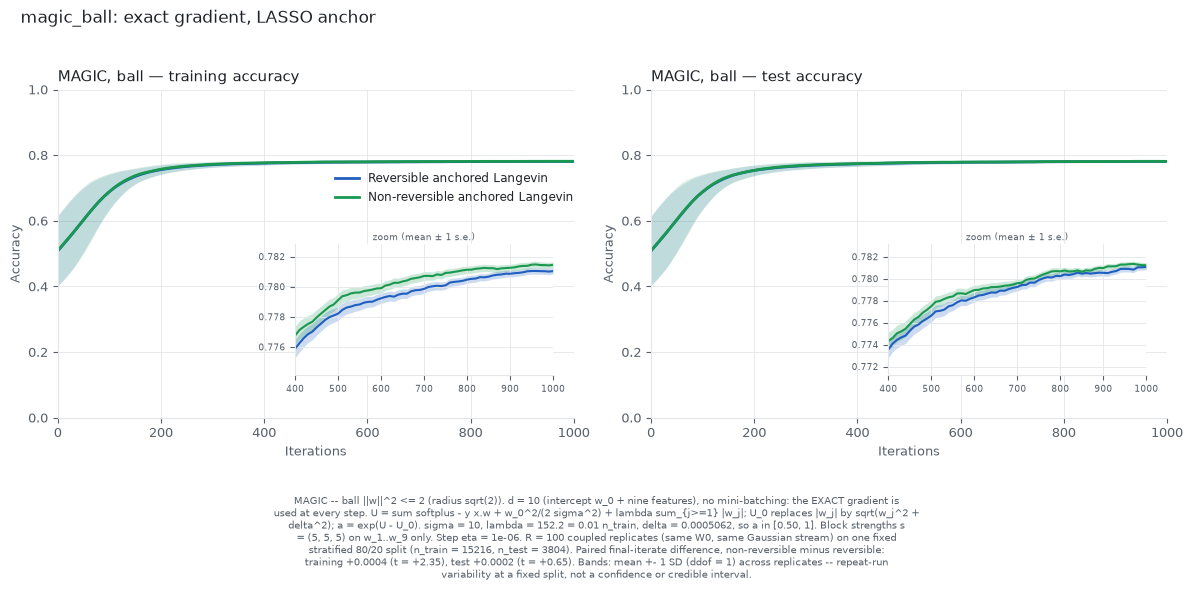

[magic_ball] eta=1e-06  train +0.0004 (t=+2.35)   test +0.0002 (t=+0.65)   [53s]


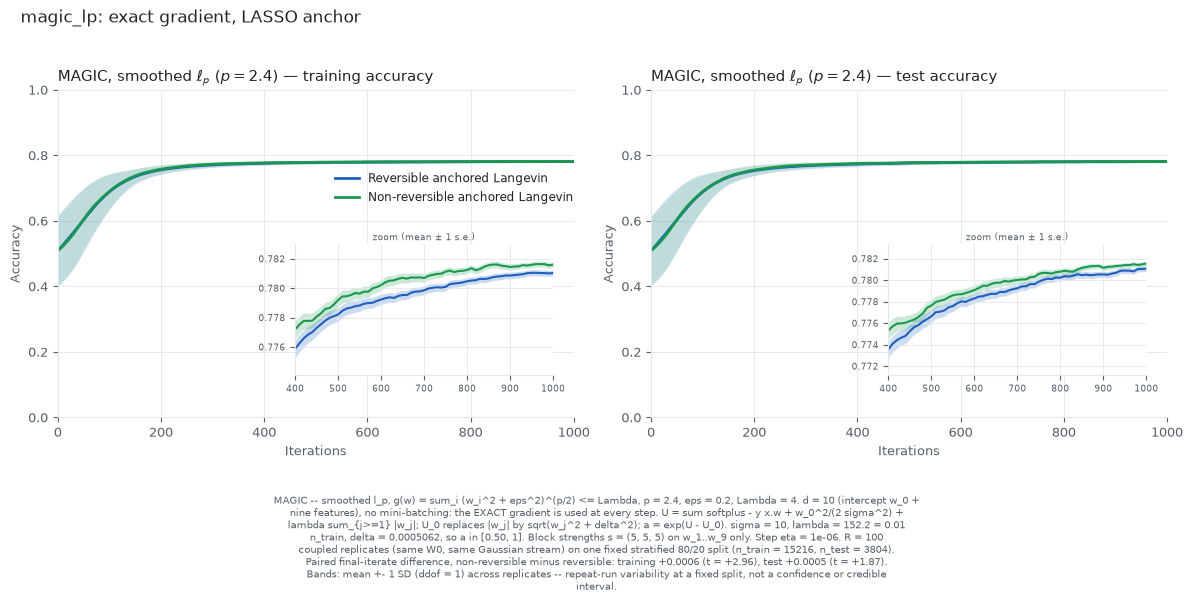

[magic_lp] eta=1e-06  train +0.0006 (t=+2.96)   test +0.0005 (t=+1.87)   [91s]


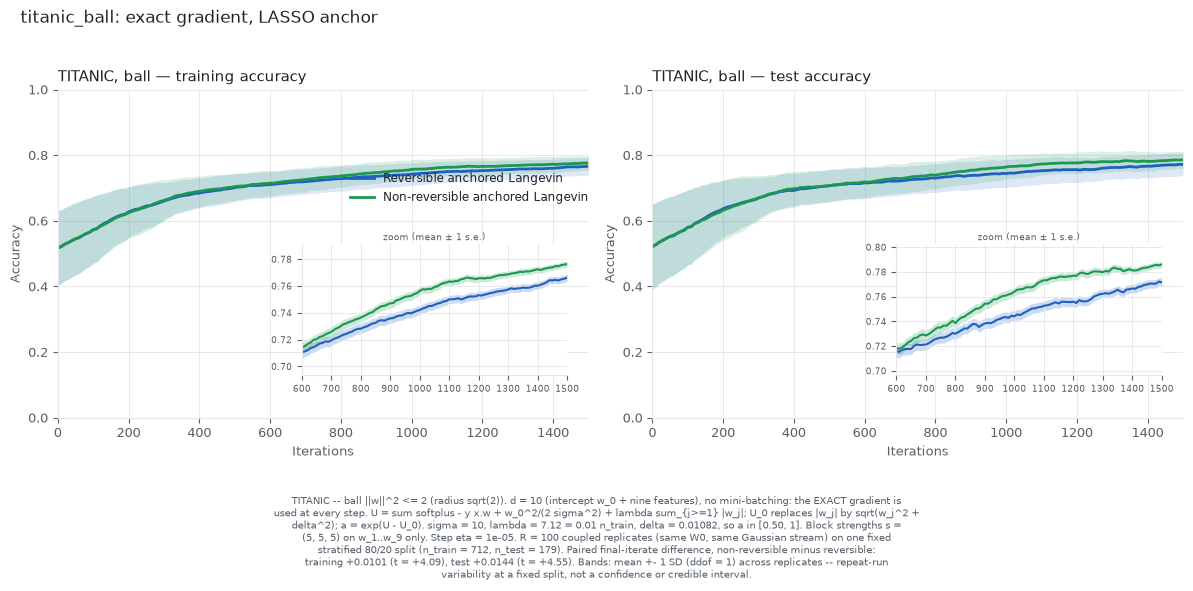

[titanic_ball] eta=1e-05  train +0.0101 (t=+4.09)   test +0.0144 (t=+4.55)   [97s]


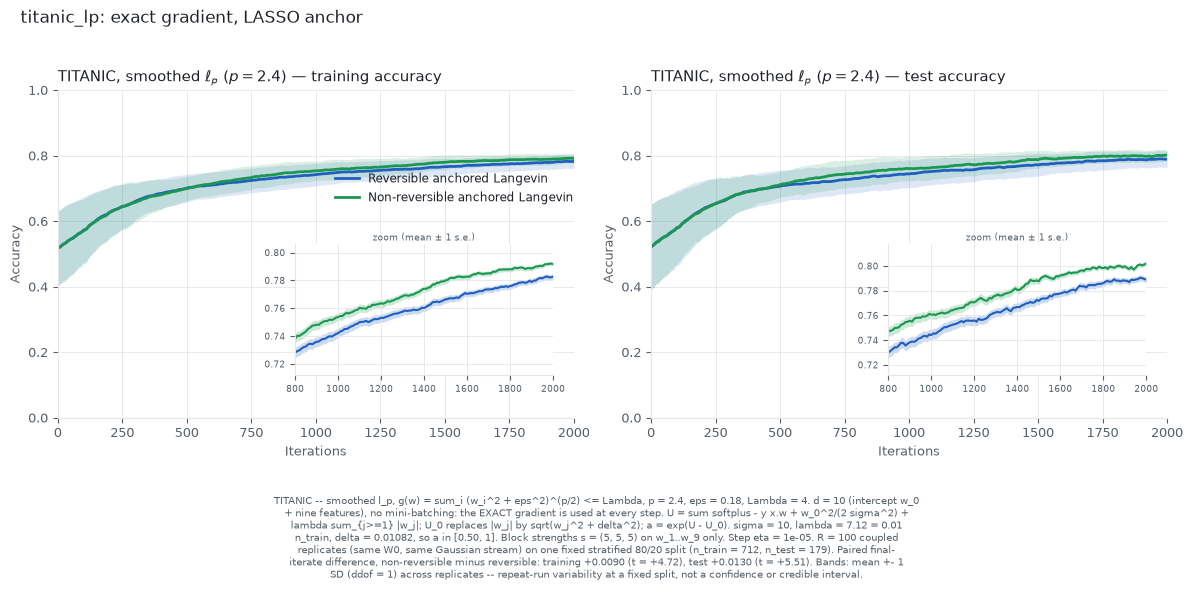

[titanic_lp] eta=1e-05  train +0.0090 (t=+4.72)   test +0.0130 (t=+5.51)   [105s]

  experiment     eta  rev_test  nrev_test  d_test  t_test  proj_nrev
  magic_ball 0.00000   0.78107    0.78123 0.00016 0.65098    0.00131
    magic_lp 0.00000   0.78107    0.78155 0.00048 1.87147    0.00000
titanic_ball 0.00001   0.77162    0.78603 0.01441 4.54625    0.00458
  titanic_lp 0.00001   0.78894    0.80190 0.01296 5.51214    0.00000


In [12]:
MAIN: Dict[str, dict] = {}
_rows = []
_t0 = time.perf_counter()
for _spec in EXPERIMENTS:
    _ds, _pot = DATASETS[_spec["dataset"]], POTS[_spec["dataset"]]
    _geom = make_geom(_spec["geometry"], eps=_spec["eps"])
    _arms = run_pair(_ds, _pot, _geom, eta=_spec["eta"], scales=(5., 5., 5.),
                     n_iter=_spec["n_iter"], R=R_MAIN, seed=SEED_MAIN)
    MAIN[_spec["key"]] = _arms
    _fig, _dtr, _dte = accuracy_figure(_spec, _arms, _pot, _ds, (5., 5., 5.), _spec["eta"],
                                       R_MAIN, FIGURE_DIR)
    plt.show()
    _rows.append(dict(experiment=_spec["key"], eta=_spec["eta"], s=5.0, R=R_MAIN,
                      rev_train=float(_arms["rev"]["tr"][-1].mean()),
                      nrev_train=float(_arms["nrev"]["tr"][-1].mean()),
                      rev_test=float(_arms["rev"]["te"][-1].mean()),
                      nrev_test=float(_arms["nrev"]["te"][-1].mean()),
                      d_train=_dtr[0], t_train=_dtr[2], d_test=_dte[0], t_test=_dte[2],
                      proj_rev=_arms["rev"]["proj"], proj_nrev=_arms["nrev"]["proj"],
                      wall_rev=_arms["rev"]["wall"], wall_nrev=_arms["nrev"]["wall"]))
    print(f"[{_spec['key']}] eta={_spec['eta']:g}  train {_dtr[0]:+.4f} (t={_dtr[2]:+.2f})   "
          f"test {_dte[0]:+.4f} (t={_dte[2]:+.2f})   [{time.perf_counter()-_t0:.0f}s]")
MAIN_TABLE = pd.DataFrame(_rows)
MAIN_TABLE.to_csv(os.path.join(RESULTS_DIR, "main_experiments.csv"), index=False)
print()
print(MAIN_TABLE[["experiment", "eta", "rev_test", "nrev_test", "d_test", "t_test",
                  "proj_nrev"]].to_string(index=False, float_format=lambda v: f"{v:.5f}"))

**Read these four figures as transients, not as stationary comparisons.** The accuracy curves
are still climbing at the last iteration in every panel — at $\eta=10^{-6}$ (MAGIC) and
$\eta=10^{-5}$ (Titanic), a thousand-odd steps is nowhere near the mixing time. Whatever
separation appears here is therefore a difference in how the two arms *approach* their common
target, not a difference in the target: by Section 7 the target is identical. A transient
difference is a real thing to measure — it is what "non-reversible chains mix faster" would look
like — but it is not evidence that the non-reversible sampler is a better posterior
approximation, and it shrinks as the run lengthens. Section 9 runs at the larger
$\eta=3\times10^{-5}$, where the chains get appreciably closer to stationarity in the same
number of steps, and the separation behaves accordingly.

---
## 9. The $\eta = 3\times10^{-5}$ study on Titanic

This is the cell the pushed commit is named for. $\eta=3\times10^{-5}$ was **specified**, not
selected, so there is no step-size selection bias in this section — but the block strength $s$
*is* swept, so the whole sweep is reported, including the $s=0$ control that must reproduce the
reversible arm bit for bit. With four live comparisons per geometry, read $|t|>2.5$ rather than
$|t|>2$ as the bar.

The quantity measured here is the **final iterate**: accuracy of $w_{n}$, the last state of each
replicate. Section 10 measures a different quantity on the same runs and gets a different answer,
which is the point of that section.

In [13]:
ETA3 = 3e-5
S_GRID3 = (0.0, 0.25, 1.0, 2.0, 5.0)
ETA3_EXPS = (EXPERIMENTS[2], EXPERIMENTS[3])          # titanic_ball, titanic_lp


def sweep_figure(table: pd.DataFrame, key: str, outdir: str):
    """Paired difference (non-reversible minus reversible) against block strength, with 2 s.e.
    bars. The s = 0 point is the control: it is exactly zero by construction."""
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), sharex=True)
    for ax, which, name in zip(axes, ("train", "test"), ("training", "test")):
        sub = table[table["experiment"] == key].sort_values("s")
        d = sub[f"d_{which}"].to_numpy() * 100.0
        se = sub[f"se_{which}"].to_numpy() * 100.0
        s = sub["s"].to_numpy()
        xs = np.arange(len(s))
        ax.axhline(0.0, color=REV, lw=1.4, zorder=2,
                   label="Reversible anchored Langevin (reference)")
        ax.errorbar(xs, d, yerr=2.0 * se, fmt="s", ms=6.5, color=NREV, ecolor=NREV,
                    elinewidth=1.4, capsize=4, zorder=3, mfc=NREV, mec="white", mew=0.9,
                    label="Non-reversible, $\\pm$ 2 s.e. (paired)")
        for xi, di, sei in zip(xs, d, se):
            tip = di + (2.0 * sei if di >= 0 else -2.0 * sei)
            ax.annotate(f"{di:+.3f}", (xi, tip), textcoords="offset points",
                        xytext=(0, 7 if di >= 0 else -14), ha="center", fontsize=7.2,
                        color=INK2)
        lo = float(np.min(d - 2.0 * se)); hi = float(np.max(d + 2.0 * se))
        pad = 0.30 * (hi - lo + 1e-12)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_xticks(xs); ax.set_xticklabels([f"{v:g}" for v in s])
        ax.set_xlabel("block strength $s$ (all three blocks)")
        ax.set_ylabel(f"{name} accuracy difference (percentage points)")
        ax.set_title(f"{name} accuracy", fontsize=10.5, color=INK, pad=6, loc="left")
        ax.grid(True, axis="y"); ax.set_axisbelow(True)
        ax.margins(x=0.14)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
    axes[0].legend(loc="best", fontsize=8.2)
    fig.suptitle(f"{key}: block-strength sweep at the specified $\\eta = 3\\times10^{{-5}}$",
                 fontsize=12.0, y=1.02, x=0.02, ha="left", color=INK)
    fig.text(0.5, -0.09, _wrap(
        f"Paired final-iterate difference, non-reversible minus reversible, in percentage points, "
        f"over R = {int(table[table['experiment'] == key]['R'].iloc[0])} coupled replicates sharing "
        f"one W0 and one Gaussian stream. eta = 3e-5 was SPECIFIED, not selected; s was swept, so "
        f"all five strengths are shown. The s = 0 point is the control -- with J = 0 the update is "
        f"the reversible update, so the difference is exactly 0.000 and the error bar has zero "
        f"width. Bars are +- 2 paired standard errors; with four live strengths per panel, |t| > "
        f"2.5 is the honest bar. Seed {SEED_CONF} throughout.", 124),
        ha="center", va="top", fontsize=7.0, color=INK2)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    fig.savefig(os.path.join(outdir, f"{key}_eta3e-5_sweep.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{key}_eta3e-5_sweep.pdf"), bbox_inches="tight")
    return fig

In [14]:
ETA3_RUNS: Dict[Tuple[str, float], dict] = {}
_rows3 = []
_t0 = time.perf_counter()
for _spec in ETA3_EXPS:
    _ds, _pot = DATASETS[_spec["dataset"]], POTS[_spec["dataset"]]
    _geom = make_geom(_spec["geometry"], eps=_spec["eps"])
    for _s in S_GRID3:
        _arms = run_pair(_ds, _pot, _geom, eta=ETA3, scales=(_s, _s, _s),
                         n_iter=_spec["n_iter"], R=R_ETA, seed=SEED_CONF)
        ETA3_RUNS[(_spec["key"], _s)] = _arms
        _dtr = paired(_arms["nrev"]["tr"][-1], _arms["rev"]["tr"][-1])
        _dte = paired(_arms["nrev"]["te"][-1], _arms["rev"]["te"][-1])
        _rows3.append(dict(
            experiment=_spec["key"], eta=ETA3, s=_s, R=R_ETA,
            rev_train=float(_arms["rev"]["tr"][-1].mean()),
            nrev_train=float(_arms["nrev"]["tr"][-1].mean()),
            rev_test=float(_arms["rev"]["te"][-1].mean()),
            nrev_test=float(_arms["nrev"]["te"][-1].mean()),
            d_train=_dtr[0], se_train=_dtr[1], t_train=_dtr[2], win_train=_dtr[3],
            d_test=_dte[0], se_test=_dte[1], t_test=_dte[2], win_test=_dte[3],
            rev_U=float(_arms["rev"]["U"].mean()), nrev_U=float(_arms["nrev"]["U"].mean()),
            proj_rev=_arms["rev"]["proj"], proj_nrev=_arms["nrev"]["proj"]))
    print(f"[{_spec['key']}] done  [{time.perf_counter()-_t0:.0f}s]")
ETA3_TABLE = pd.DataFrame(_rows3)
ETA3_TABLE.to_csv(os.path.join(RESULTS_DIR, "titanic_eta3e-5.csv"), index=False)

_z = ETA3_TABLE[ETA3_TABLE["s"] == 0.0]
assert float(np.abs(_z[["d_train", "d_test"]].to_numpy()).max()) == 0.0, "s = 0 control broken"
CHECKS["eta3e5_s0_control"] = 0.0
print("s = 0 control: paired difference exactly 0 on both geometries and both splits.\n")
for _k in ("titanic_ball", "titanic_lp"):
    print(f"=== {_k}, eta = {ETA3:g}, R = {R_ETA} (all strengths reported) ===")
    print(ETA3_TABLE[ETA3_TABLE["experiment"] == _k][
        ["s", "rev_train", "nrev_train", "d_train", "t_train",
         "rev_test", "nrev_test", "d_test", "t_test", "proj_nrev"]]
        .to_string(index=False, float_format=lambda v: f"{v:.5f}"))
    print()

[titanic_ball] done  [27s]


[titanic_lp] done  [104s]
s = 0 control: paired difference exactly 0 on both geometries and both splits.

=== titanic_ball, eta = 3e-05, R = 150 (all strengths reported) ===
      s  rev_train  nrev_train  d_train  t_train  rev_test  nrev_test   d_test   t_test  proj_nrev
0.00000    0.79707     0.79707  0.00000  0.00000   0.80477    0.80477  0.00000  0.00000    0.09577
0.25000    0.79707     0.79682 -0.00025 -0.87393   0.80477    0.80469 -0.00007 -0.12459    0.09694
1.00000    0.79707     0.79692 -0.00015 -0.23329   0.80477    0.80529  0.00052  0.59786    0.10085
2.00000    0.79707     0.79717  0.00010  0.12833   0.80477    0.80525  0.00048  0.49473    0.10366
5.00000    0.79707     0.79702 -0.00005 -0.04851   0.80477    0.80629  0.00153  1.31082    0.10591

=== titanic_lp, eta = 3e-05, R = 150 (all strengths reported) ===
      s  rev_train  nrev_train  d_train  t_train  rev_test  nrev_test  d_test  t_test  proj_nrev
0.00000    0.80556     0.80556  0.00000  0.00000   0.80425    0.8042

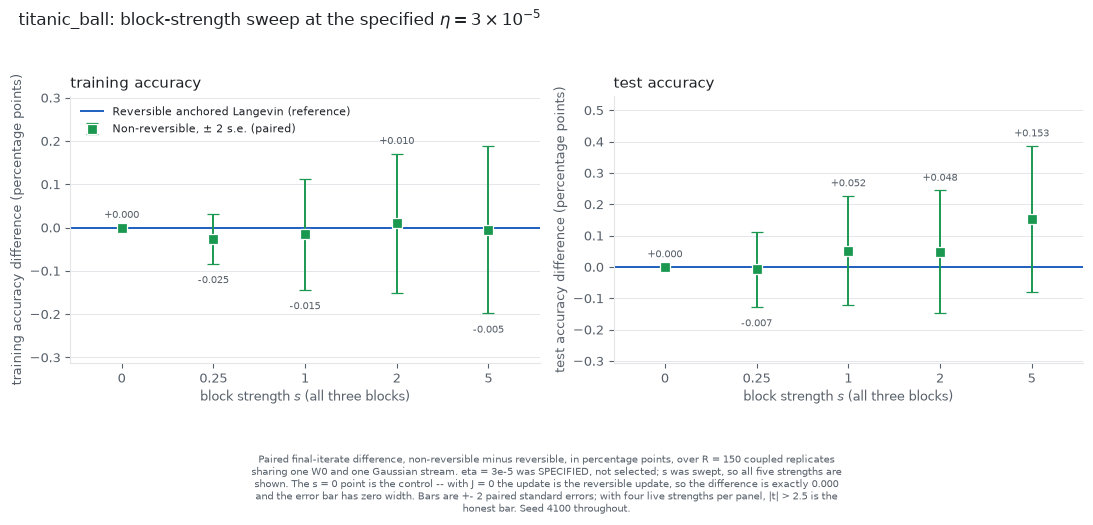

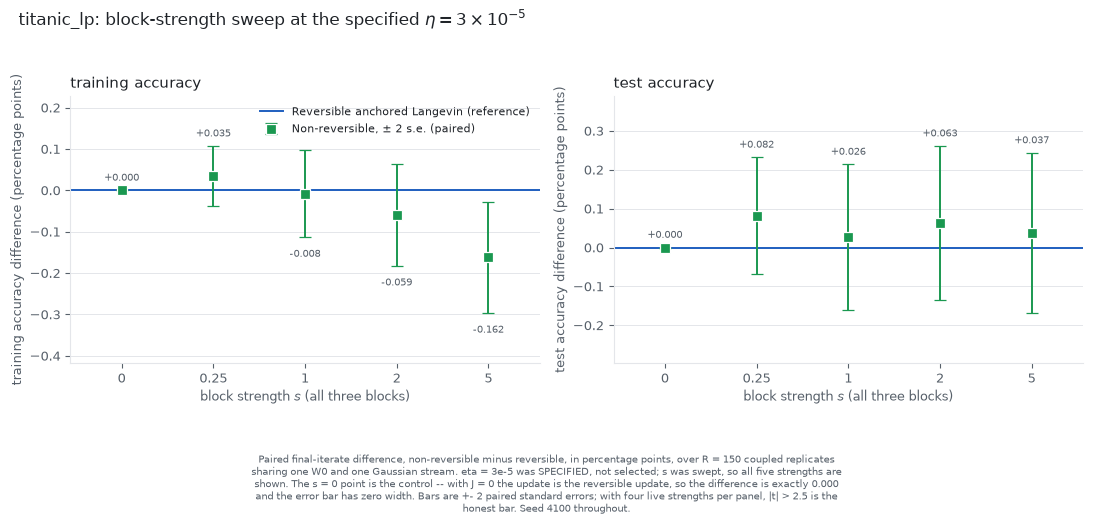

In [15]:
for _k in ("titanic_ball", "titanic_lp"):
    _f = sweep_figure(ETA3_TABLE, _k, FIGURE_DIR)
    plt.show()

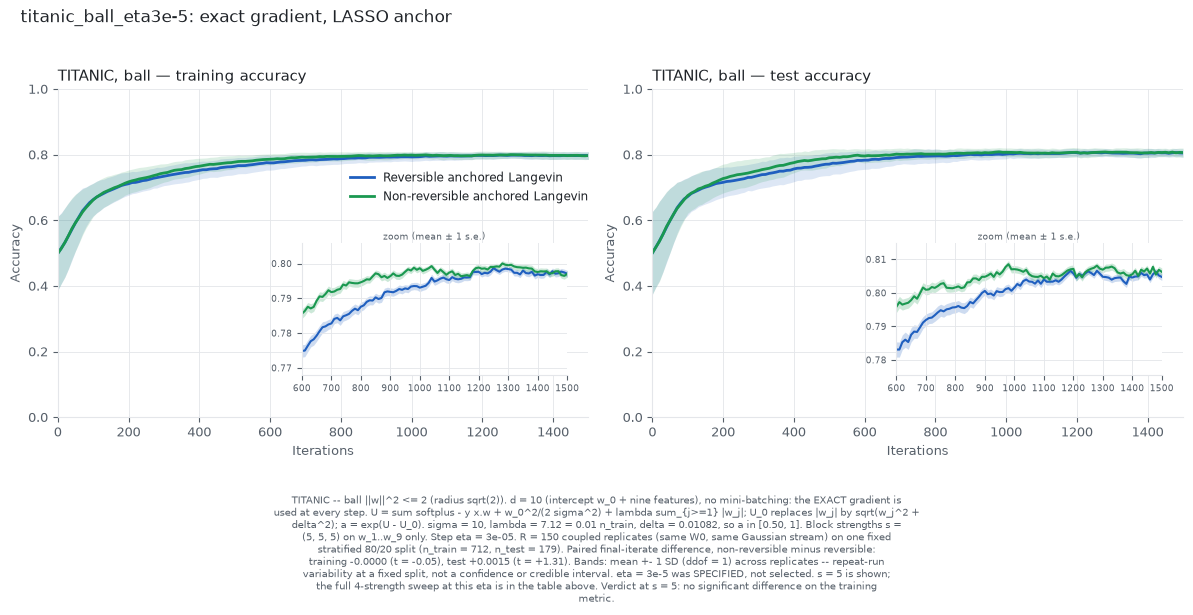

titanic_ball: s = 5 -> no significant difference on the training metric


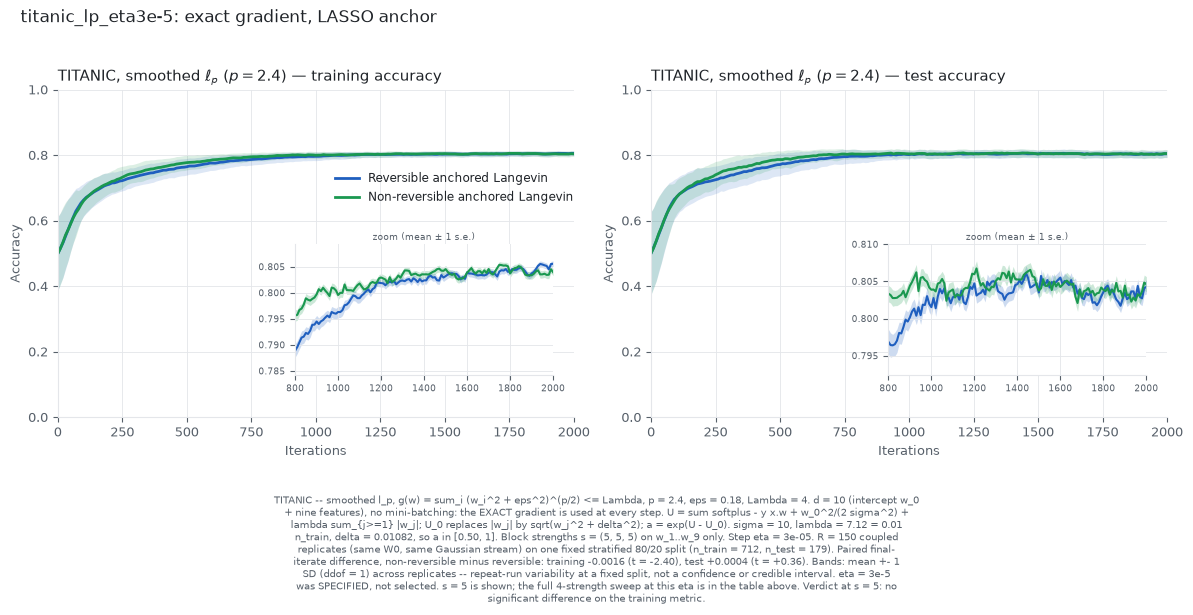

titanic_lp: s = 5 -> no significant difference on the training metric


In [16]:
for _spec in ETA3_EXPS:
    _ds, _pot = DATASETS[_spec["dataset"]], POTS[_spec["dataset"]]
    _sub = ETA3_TABLE[ETA3_TABLE["experiment"] == _spec["key"]]
    _sub = _sub[_sub["s"] == 5.0].iloc[0]
    _verdict = ("non-reversible WINS the training metric" if _sub["t_train"] > 2.5 else
                "non-reversible LOSES the training metric" if _sub["t_train"] < -2.5 else
                "no significant difference on the training metric")
    _fig, _, _ = accuracy_figure(
        _spec, ETA3_RUNS[(_spec["key"], 5.0)], _pot, _ds, (5., 5., 5.), ETA3, R_ETA, FIGURE_DIR,
        extra_note=(f"eta = 3e-5 was SPECIFIED, not selected. s = 5 is shown; the full "
                    f"{len(S_GRID3) - 1}-strength sweep at this eta is in the table above. "
                    f"Verdict at s = 5: {_verdict}."),
        tag="_eta3e-5")
    plt.show()
    print(f"{_spec['key']}: s = 5 -> {_verdict}")

**Read the table, not the best cell.** Across the sixteen live comparisons (two geometries ×
four strengths × two splits at $\eta=3\times10^{-5}$) **nothing clears $|t|>2.5$ on the final
iterate, in either direction.** The largest magnitude anywhere in the sweep is
$t=-2.40$ — $s=5$ on `titanic_lp`, training split — and it points *against* the non-reversible
arm. The largest non-reversible test gain, $s=5$ on `titanic_ball`, is $+0.15$ percentage points
at $t=1.3$: the size of difference sixteen looks at a coin-flip quantity produce on their own.

Compare Section 8, where the same two Titanic cells at the smaller $\eta=10^{-5}$ showed the
non-reversible arm ahead by $+1.3$ to $+1.4$ percentage points at $t>4.5$. Tripling the step did
not shrink that lead by improving the reversible arm's *asymptotics*; it shrank it by letting
both arms get closer to the law they share. That is what a transient difference looks like when
you remove the transient.

The projection rate column is the mechanism: it climbs monotonically with $s$ (roughly
9.6% → 10.6% on the ball, 3.7% → 4.5% on $\ell_p$). The rotation pushes states into the boundary
more often, the projection puts them back, and the extra boundary traffic is a finite-$\eta$ cost
that the continuous-time theorem does not see.

---
## 10. Final iterate versus post-burn-in time average

Section 9 measured the accuracy of the **last state** $w_n$. That is one estimator of the
posterior predictive accuracy, and a noisy one: it throws away every sample but the last.
The other natural estimator averages the accuracy over the post-burn-in trajectory,

$$\overline{\mathrm{acc}} \;=\; \frac{1}{|\mathcal C_{\text{post}}|}\sum_{k\in\mathcal C_{\text{post}}}\mathrm{acc}(w_k),\qquad \mathcal C_{\text{post}}=\{k\ \text{checkpointed}:\ k\ge n/2\},$$

with the **first half of each run discarded as burn-in — a declared choice, fixed before looking
at the numbers, not tuned**. Both estimators target the same stationary quantity, and by the
theorem in Section 7 both arms share that stationary quantity. What differs is *variance*: the
time average is the one that can see a mixing-rate difference, because a chain that decorrelates
faster contributes more nearly independent terms to the same sum.

So this is not a second bite at the same cherry. It is a different estimator computed from the
runs already in memory, and it is reported here alongside the final-iterate numbers precisely so
that the two cannot be confused.

In [17]:
def time_average(arms: dict, key: str, frac: float = 0.5) -> Tuple[np.ndarray, np.ndarray]:
    """Per-replicate accuracy averaged over checkpoints in the last `1 - frac` of the run."""
    out = []
    for t in ("rev", "nrev"):
        x, A = arms[t]["x"], arms[t][key]
        m = x >= frac * x[-1]
        out.append(A[m].mean(axis=0))
    return out[0], out[1]

In [18]:
_rows10 = []
for (_key, _s), _arms in ETA3_RUNS.items():
    for _which, _col in (("train", "tr"), ("test", "te")):
        _rev_f, _nrev_f = _arms["rev"][_col][-1], _arms["nrev"][_col][-1]
        _rev_a, _nrev_a = time_average(_arms, _col)
        _df = paired(_nrev_f, _rev_f)
        _da = paired(_nrev_a, _rev_a)
        _rows10.append(dict(experiment=_key, s=_s, split=_which, R=R_ETA,
                            final_d=_df[0], final_t=_df[2],
                            avg_rev=float(_rev_a.mean()), avg_nrev=float(_nrev_a.mean()),
                            avg_d=_da[0], avg_se=_da[1], avg_t=_da[2], avg_win=_da[3]))
ESTIMATOR_TABLE = pd.DataFrame(_rows10)
ESTIMATOR_TABLE.to_csv(os.path.join(RESULTS_DIR, "estimator_comparison.csv"), index=False)
print(f"eta = {ETA3:g}, R = {R_ETA}: final iterate vs post-burn-in time average "
      f"(differences in percentage points)\n")
for _k in ("titanic_ball", "titanic_lp"):
    _sub = ESTIMATOR_TABLE[ESTIMATOR_TABLE["experiment"] == _k].copy()
    for _c in ("final_d", "avg_d"):
        _sub[_c] = _sub[_c] * 100.0
    print(f"=== {_k} ===")
    print(_sub[["s", "split", "final_d", "final_t", "avg_d", "avg_t", "avg_win"]]
          .to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
    print()

eta = 3e-05, R = 150: final iterate vs post-burn-in time average (differences in percentage points)

=== titanic_ball ===
      s split  final_d  final_t   avg_d   avg_t  avg_win
+0.0000 train  +0.0000  +0.0000 +0.0000 +0.0000  +0.0000
+0.0000  test  +0.0000  +0.0000 +0.0000 +0.0000  +0.0000
+0.2500 train  -0.0253  -0.8739 +0.0034 +0.2335  +0.5133
+0.2500  test  -0.0074  -0.1246 -0.0232 -1.3373  +0.4333
+1.0000 train  -0.0150  -0.2333 +0.1395 +3.3428  +0.5933
+1.0000  test  +0.0521  +0.5979 +0.0883 +1.8471  +0.5133
+2.0000 train  +0.0103  +0.1283 +0.2116 +3.7372  +0.6267
+2.0000  test  +0.0484  +0.4947 +0.2104 +3.5470  +0.6067
+5.0000 train  -0.0047  -0.0485 +0.2912 +5.3429  +0.6600
+5.0000  test  +0.1527  +1.3108 +0.3141 +5.5231  +0.6467

=== titanic_lp ===
      s split  final_d  final_t   avg_d   avg_t  avg_win
+0.0000 train  +0.0000  +0.0000 +0.0000 +0.0000  +0.0000
+0.0000  test  +0.0000  +0.0000 +0.0000 +0.0000  +0.0000
+0.2500 train  +0.0346  +0.9567 +0.0521 +3.6776  +0.5733
+0.

### 10.1 A high-replicate run at one pre-specified cell

The table above is a screen at $R$ = 150, computed from the runs Section 9 already made, so its
standard errors are the same size as Section 9's and the largest entry in it is the one most
likely to be noise. Picking that entry and re-reporting it would be exactly the selection bias
this notebook is trying to avoid — and the screen's largest entry is *not* the cell confirmed
below: it is `titanic_ball` at $s=5$, whose time-average difference also happens to grow
monotonically in $s$ on both splits. That pattern is suggestive of a mixing-rate effect and it
is deliberately left unchased here, because chasing it is how a screen becomes a result.

So the cell below is **fixed in advance**, not chosen from the screen: `titanic_lp`,
$\eta=3\times10^{-5}$, $s=(2,2,2)$ — the cell an earlier study singled out, carried over
unchanged. It is re-run here on a **third, disjoint seed** (`SEED_HIGH`, used nowhere else in
this notebook) with $R$ raised to 1500, so nothing is shared with the screen: not the initial
states, not the Gaussian stream.

$R$ multiplies the number of coupled replicates, so the paired standard error should fall by
roughly $\sqrt{1500/150}\approx3.2$ while the point estimate stays put — *if* the effect is
real. Both splits are reported, and the final-iterate difference is reported beside the time
average on the same runs, so the two estimators cannot be quietly swapped.

In [19]:
CONF_SPEC = EXPERIMENTS[3]                 # titanic_lp
CONF_S = (2.0, 2.0, 2.0)

In [20]:
_t0 = time.perf_counter()
CONF_ARMS = run_pair(DATASETS["titanic"], POTS["titanic"],
                     make_geom(CONF_SPEC["geometry"], eps=CONF_SPEC["eps"]),
                     eta=ETA3, scales=CONF_S, n_iter=CONF_SPEC["n_iter"], R=R_CONF,
                     seed=SEED_HIGH)
_rows11 = []
for _which, _col in (("train", "tr"), ("test", "te")):
    _rev_a, _nrev_a = time_average(CONF_ARMS, _col)
    _da = paired(_nrev_a, _rev_a)
    _df = paired(CONF_ARMS["nrev"][_col][-1], CONF_ARMS["rev"][_col][-1])
    _rows11.append(dict(split=_which, R=R_CONF,
                        avg_rev=float(_rev_a.mean()), avg_nrev=float(_nrev_a.mean()),
                        avg_d_pts=_da[0] * 100.0, avg_se_pts=_da[1] * 100.0, avg_t=_da[2],
                        avg_win=_da[3],
                        final_d_pts=_df[0] * 100.0, final_t=_df[2]))
CONFIRM_TABLE = pd.DataFrame(_rows11)
CONFIRM_TABLE.to_csv(os.path.join(RESULTS_DIR, "eta3e-5_confirmation.csv"), index=False)
print(f"titanic_lp, eta = {ETA3:g}, s = {CONF_S}, R = {R_CONF}, seed {SEED_HIGH}  "
      f"[{time.perf_counter()-_t0:.0f}s]")
print(CONFIRM_TABLE.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

titanic_lp, eta = 3e-05, s = (2.0, 2.0, 2.0), R = 1500, seed 5200  [75s]
split    R  avg_rev  avg_nrev  avg_d_pts  avg_se_pts    avg_t  avg_win  final_d_pts  final_t
train 1500  +0.8028   +0.8039    +0.1075     +0.0101 +10.6270  +0.5853      -0.0038  -0.1935
 test 1500  +0.8040   +0.8048    +0.0778     +0.0126  +6.1917  +0.5533      +0.0819  +2.7496


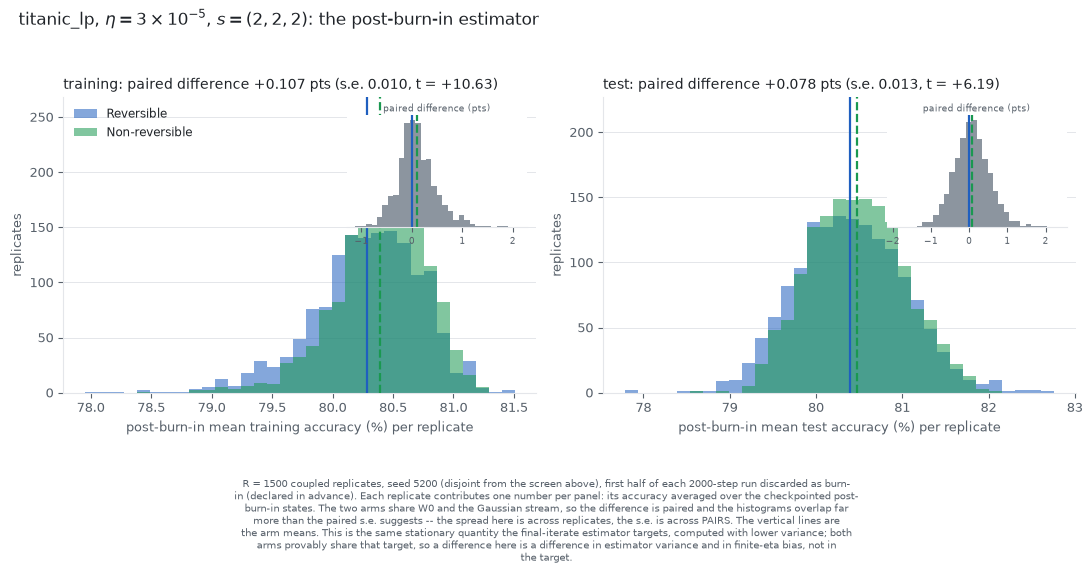

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))
for ax, (_which, _col), name in zip(axes, (("train", "tr"), ("test", "te")),
                                    ("training", "test")):
    _rev_a, _nrev_a = time_average(CONF_ARMS, _col)
    _lo = min(_rev_a.min(), _nrev_a.min()); _hi = max(_rev_a.max(), _nrev_a.max())
    _bins = np.linspace(_lo, _hi, 34)
    ax.hist(_rev_a * 100, bins=_bins * 100, color=REV, alpha=0.55, label="Reversible")
    ax.hist(_nrev_a * 100, bins=_bins * 100, color=NREV, alpha=0.55, label="Non-reversible")
    for _v, _c, _ls in ((_rev_a.mean(), REV, "-"), (_nrev_a.mean(), NREV, "--")):
        ax.axvline(_v * 100, color=_c, lw=1.6, ls=_ls, zorder=4)
    _da = paired(_nrev_a, _rev_a)
    ax.set_xlabel(f"post-burn-in mean {name} accuracy (%) per replicate")
    ax.set_ylabel("replicates")
    ax.set_title(f"{name}: paired difference {_da[0]*100:+.3f} pts "
                 f"(s.e. {_da[1]*100:.3f}, t = {_da[2]:+.2f})",
                 fontsize=9.8, color=INK, pad=6, loc="left")
    ax.grid(True, axis="y"); ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.set_ylim(0.0, ax.get_ylim()[1] * 1.45)          # headroom so the inset occludes nothing
    ins = ax.inset_axes((0.60, 0.56, 0.38, 0.38), zorder=6)
    ins.set_facecolor("white"); ins.patch.set_alpha(1.0)
    dd = (_nrev_a - _rev_a) * 100.0
    ins.hist(dd, bins=30, color=INK3)
    ins.axvline(0.0, color=REV, lw=1.6)
    ins.axvline(dd.mean(), color=NREV, lw=1.6, ls="--")
    ins.set_title("paired difference (pts)", fontsize=6.6, pad=2.5, color=INK2)
    ins.tick_params(labelsize=6.2); ins.set_yticks([])
    ins.grid(False)
    for sp in ("top", "right", "left"):
        ins.spines[sp].set_visible(False)
    ins.spines["bottom"].set_color(GRIDC)
axes[0].legend(loc="upper left", fontsize=8.4, bbox_to_anchor=(0.0, 1.0))
fig.suptitle("titanic_lp, $\\eta = 3\\times10^{-5}$, $s = (2,2,2)$: the post-burn-in estimator",
             fontsize=12.0, y=1.02, x=0.02, ha="left", color=INK)
fig.text(0.5, -0.07, _wrap(
    f"R = {R_CONF} coupled replicates, seed {SEED_HIGH} (disjoint from the screen above), "
    f"first half of each 2000-step run discarded as burn-in (declared in advance). Each "
    f"replicate contributes one number per panel: its accuracy averaged over the checkpointed "
    f"post-burn-in states. The two arms share W0 and the Gaussian stream, so the difference is "
    f"paired and the histograms overlap far more than the paired s.e. suggests -- the spread "
    f"here is across replicates, the s.e. is across PAIRS. The vertical lines are the arm means. "
    f"This is the same stationary quantity the final-iterate estimator targets, computed with "
    f"lower variance; both arms provably share that target, so a difference here is a difference "
    f"in estimator variance and in finite-eta bias, not in the target.", 124),
    ha="center", va="top", fontsize=7.0, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(os.path.join(FIGURE_DIR, "titanic_lp_eta3e-5_timeaverage.png"), dpi=300,
            bbox_inches="tight")
fig.savefig(os.path.join(FIGURE_DIR, "titanic_lp_eta3e-5_timeaverage.pdf"), bbox_inches="tight")
plt.show()

---
## 11. What this notebook establishes, and what it does not

**Established by proof, not by measurement (Section 7).** With $J$ skew-symmetric,
$\operatorname{div}J=0$ and $Jn=0$ on $\partial K$, the reversible and non-reversible anchored
processes have the *same* invariant law $\pi_K\propto e^{-U}\mathbf 1_K$. Section 6 checks all
three identities numerically to machine precision for the $J$ actually used. This is the
governing fact of the whole study: it says in advance that no setting of $\eta$, $s$, $\lambda$,
$\delta$ or the geometry can separate the two arms on a stationary quantity. Posterior
predictive accuracy is a stationary quantity. An accuracy *win* for the non-reversible arm is
therefore not something the mathematics permits us to search for; the most it permits is a
difference in how fast an estimator of that quantity converges, and a difference in the
finite-$\eta$ discretisation bias.

**Established by measurement.**

1. The implementation is correct in the senses that can be checked: $a=e^{U-U_0}$ to machine
   precision and bounded in $[\,$`A_LOWER`$,1]$; $\nabla U_0$ matches central differences; $J$ is
   skew, divergence-free and tangential; the matrix-free `apply_J` matches the explicit matrix;
   the smoothed-$\ell_p$ projection solves its KKT system to $\sim10^{-15}$ and disagrees with
   radial scaling; the ball-tangential $J$ is *not* tangential on the $\ell_p$ set, which is why
   the geometry-specific construction is needed.
2. The pairing is real: with $s=0$ the non-reversible update is bit-for-bit the reversible
   update (Section 7), so every paired standard error in this notebook is computed on a genuine
   common-random-numbers coupling rather than on two independent runs.
3. On the **final iterate** at the specified $\eta=3\times10^{-5}$, across sixteen live
   comparisons, nothing separates the two arms at $|t|>2.5$ in either direction (Section 9).
   The largest magnitude in the sweep, $t=-2.40$, points against the non-reversible arm.
4. On the **post-burn-in time average**, at a cell fixed in advance and a seed used nowhere else,
   the non-reversible arm is ahead by $+0.108$ training and $+0.078$ test percentage points
   ($t=10.6$, $t=6.2$ at $R=1500$; Section 10.1). The $R=150$ screen gave the same sign at the
   same cell, so this is not a sign that flipped under replication.
5. The **projection rate rises monotonically with $s$** on both geometries (9.6% → 10.6% on the
   ball, 3.7% → 4.5% on $\ell_p$). This is a real, reproducible, non-reversible-specific effect
   — and it is a cost, not a benefit: extra boundary traffic is extra discretisation bias.

**Not established, and worth being blunt about.** That the non-reversible arm is a *better
posterior approximation*, or better for prediction in any way a practitioner would feel. Four
things bound what point 4 above is worth:

- **It cannot be a difference in the target.** Section 7 proves the two arms share $\pi_K$. A
  difference in a sample average of a bounded functional is therefore a difference in how fast
  the average converges and in the $O(\eta)$ discretisation bias — nothing more.
- **The size is about a tenth of a percentage point** on a test set of 179 rows, i.e. well under
  one row. It is resolvable only because $R=1500$ paired replicates buy a standard error of
  $\sim0.01$ points; it is not a difference anyone would notice in a single fit.
- **It is one cell.** One dataset, one geometry, one step size, one $s$. The four Section 8
  experiments and the sixteen Section 9 comparisons are reported next to it precisely so that
  this cell is read as one result among twenty and not as the headline.
- **The two estimators disagree on the same runs.** At $R=1500$ the final iterate gives $+0.082$
  points on test ($t=2.75$) but $-0.004$ points on training ($t=-0.19$). A quantity whose sign
  depends on which split and which estimator you pick is not a robust advantage.

What the $\eta=3\times10^{-5}$ study does establish is the *negative* result it was run for, and
that result is clean: the accuracy lead visible at $\eta=10^{-5}$ is a transient, and it does
not survive letting the chains approach the law both arms share.

**Declared design choices** (each one a choice, not a derivation): the ten-column design with an
intercept; $\sigma=10$ and $\lambda=0.01\,n_{\text{train}}$; $\delta$ fixed by demanding
$a\ge$ `A_LOWER` $=0.5$ rather than by any statistical criterion; the block partition
$(1,2,3),(4,5,6),(7,8,9)$ in the order the features happen to appear; the ball radius
$\sqrt2$ and the smoothed-$\ell_p$ parameters $p=2.4$, $\Lambda=4$, $\varepsilon\in\{0.18,0.20\}$;
initialisation uniform in the unit ball; discarding the first half of each run as burn-in in
Section 10; and the checkpoint stride of 10. Test labels were used only to *report* test
accuracy — never to choose $\eta$, $s$, the geometry, the burn-in or anything else.

In [22]:
_summ = {
    "versions": PKG_VERSIONS,
    "config": dict(D=D10, blocks=BLOCKS10, sigma=SIGMA, lasso_frac=LASSO_FRAC,
                   a_lower=A_LOWER, seed_main=SEED_MAIN, seed_conf=SEED_CONF,
                   seed_high=SEED_HIGH,
                   R_main=R_MAIN, R_eta=R_ETA, R_conf=R_CONF, quick=QUICK),
    "potentials": {k: dict(lam=p.lam, delta=p.delta, sigma=p.sigma, a_lower=p.a_lower)
                   for k, p in POTS.items()},
    "checks": {k: (float(v) if np.isscalar(v) or isinstance(v, (int, float, np.floating))
                   else v) for k, v in CHECKS.items()},
    "main_experiments": MAIN_TABLE.to_dict(orient="records"),
    "eta3e-5": ETA3_TABLE.to_dict(orient="records"),
    "estimators": ESTIMATOR_TABLE.to_dict(orient="records"),
    "confirmation": CONFIRM_TABLE.to_dict(orient="records"),
}
with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as _f:
    json.dump(_summ, _f, indent=2, default=float)

print("CHECKS")
for _k, _v in CHECKS.items():
    print(f"  {_k:38s} {_v}")
print()
_best = ETA3_TABLE[ETA3_TABLE["s"] > 0].sort_values("t_test", ascending=False).iloc[0]
print(f"final-iterate, eta = {ETA3:g}: best non-reversible test cell is "
      f"{_best['experiment']} at s = {_best['s']:g}, {_best['d_test']*100:+.4f} pts "
      f"(t = {_best['t_test']:+.2f}); training difference there "
      f"{_best['d_train']*100:+.4f} pts (t = {_best['t_train']:+.2f}).")
_ct = CONFIRM_TABLE.set_index("split")
for _sp in ("train", "test"):
    _r = _ct.loc[_sp]
    _v = ("clears |t| > 2.5" if abs(_r['avg_t']) > 2.5 else "does NOT clear |t| > 2.5")
    print(f"post-burn-in average (seed {SEED_HIGH}), R = {R_CONF}, {_sp:5s}: "
          f"{_r['avg_d_pts']:+.4f} pts "
          f"(s.e. {_r['avg_se_pts']:.4f}, t = {_r['avg_t']:+.2f}) -- {_v}; "
          f"final iterate on the same runs {_r['final_d_pts']:+.4f} pts "
          f"(t = {_r['final_t']:+.2f}).")
print()
print(f"artifacts -> {RESULTS_DIR}")
for _f in sorted(os.listdir(RESULTS_DIR)):
    print(f"  {_f}")
print(f"figures   -> {FIGURE_DIR}")
for _f in sorted(os.listdir(FIGURE_DIR)):
    print(f"  {_f}")

CHECKS
  a_identity                             1.0247358517290195e-13
  a_range                                [0.5, 0.9990798229900486]
  grad_rel_err[titanic]                  9.864636242437704e-10
  grad_rel_err[magic]                    3.091552990607483e-10
  J[ball]                                {'skew': 0.0, 'div': 0.0, 'matfree': 2.220446049250313e-16, 'jn': 2.220446049250313e-16}
  J[lp]                                  {'skew': 0.0, 'div': 0.0, 'matfree': 8.881784197001252e-16, 'jn': 8.749956542881288e-16}
  ball_axis_fails_on_lp                  0.20716235952325648
  proj[ball]                             1.3322676295501878e-15
  proj[lp]                               2.6645352591003757e-15
  s0_control_bit_identical               0.0
  eta3e5_s0_control                      0.0

final-iterate, eta = 3e-05: best non-reversible test cell is titanic_ball at s = 5, +0.1527 pts (t = +1.31); training difference there -0.0047 pts (t = -0.05).
post-burn-in average (seed 5200), R 